# Machine Learning Models for Electricity Demand Forecasting

In this notebook we train and evaluate several machine learning models
to forecast electricity demand.

The goal is to determine whether machine learning models can outperform
the seasonal naive baseline established in the previous notebook.

Models evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Defining baseline metrics
baseline_test_metrics = {
    "model": "Baseline (Lag-24)",
    "MAE": 2298.79,
    "MAPE": 4.65
}

In [3]:
df = pd.read_csv(
    "../data/processed/features_dataset.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

In [4]:
print(df.shape)
display(df.head())

(52416, 21)


,demand_MW,temperature,time_of_day,is_weekend,season,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_24,...,rolling_mean_168,temp_lag_1,temp_lag_3,temp_lag_24,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:00:00,32107.0,16.9,Night,0,winter,34384.0,38918.0,50863.0,35720.666667,34891.583333,...,46432.279762,18.8,21.4,12.6,0.000000,1.000000,0.0,1.0,0.5,0.866025
2018-01-08 01:00:00,30797.0,15.9,Night,0,winter,33093.0,37868.0,50587.0,34035.333333,34796.708333,...,46320.636905,16.9,20.3,12.4,0.258819,0.965926,0.0,1.0,0.5,0.866025
2018-01-08 02:00:00,30261.0,16.4,Night,0,winter,32214.0,37441.0,50650.0,32320.000000,34701.041667,...,46202.839286,15.9,18.8,11.9,0.500000,0.866025,0.0,1.0,0.5,0.866025
2018-01-08 03:00:00,30210.0,16.2,Night,0,winter,31731.0,37431.0,50737.0,31055.000000,34619.666667,...,46081.476190,16.4,16.9,11.4,0.707107,0.707107,0.0,1.0,0.5,0.866025
2018-01-08 04:00:00,30763.0,15.8,Night,0,winter,31529.0,37865.0,51021.0,30422.666667,34556.291667,...,45959.291667,16.2,15.9,11.0,0.866025,0.500000,0.0,1.0,0.5,0.866025


In [5]:
df = df.drop(columns=["time_of_day", "season"]) 
# Drop categorical features for now, since they are redundant as we have hour_of_day and month columns, to capture the same information in a more granular way.

In [6]:
# Split the data into training, validation, and test sets based on time
train = df.loc[: "2021-12-31"]
val = df.loc["2022-01-01" : "2022-12-31"]
test = df.loc["2023-01-01" :]   

print(f"Train shape: {train.shape}")
print(f"Validation shape: {val.shape}")
print(f"Test shape: {test.shape}")

Train shape: (34896, 19)
Validation shape: (8760, 19)
Test shape: (8760, 19)


In [7]:
# Splitting into features and target
# The target variable is 'demand_MW' and the rest are features.
X_train = train.drop(columns=["demand_MW"])
y_train = train["demand_MW"]

X_val = val.drop(columns=["demand_MW"])
y_val = val["demand_MW"]

X_test = test.drop(columns=["demand_MW"])
y_test = test["demand_MW"]

In [8]:
# Evaluation function 
from sklearn.metrics import mean_absolute_error

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = float((abs((y_true - y_pred) / y_true)).mean() * 100)

    return {
        "model": name,
        "MAE": mae,
        "MAPE": mape
    }

## Linear Regression
A simple linear model is used as the first machine learning approach.
It models demand as a linear combination of lag features, calendar
features, and weather variables.

In [9]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_val_pred = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

In [10]:
lr_val_metrics = evaluate_model("Linear Regression", y_val, lr_val_pred)
lr_test_metrics = evaluate_model("Linear Regression", y_test, lr_test_pred)
print("Validation Metrics:", lr_val_metrics)
print("Test Metrics:", lr_test_metrics)

Validation Metrics: {'model': 'Linear Regression', 'MAE': 1584.8884865069751, 'MAPE': 3.246035216862756}
Test Metrics: {'model': 'Linear Regression', 'MAE': 1455.4556228323283, 'MAPE': 2.870558844214952}


### Linear Regression Results

The linear regression model improves significantly upon the seasonal naive baseline.

| Model | MAE | MAPE |
|------|------|------|
| Baseline (Lag-24) | ~2299 MW | ~4.65% |
| Linear Regression | ~1455 MW | ~2.87% |

The improvement demonstrates that incorporating lagged demand, rolling statistics, calendar features, and temperature allows the model to capture additional structure in electricity demand beyond simple daily repetition.

Despite its simplicity, the linear model performs strongly due to the high autocorrelation present in electricity demand time series.

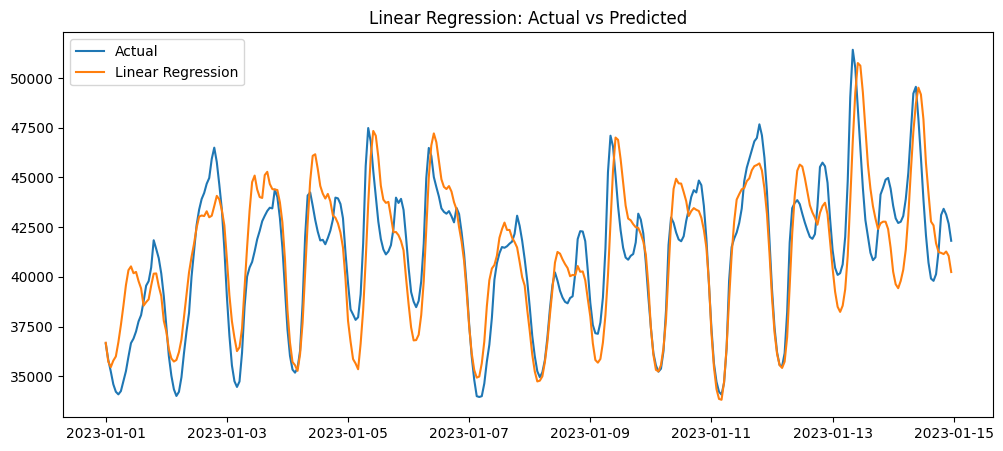

In [11]:
lr_test_pred = pd.Series(lr_test_pred, index=y_test.index) # Convert predictions to a Pandas Series

subset = y_test.loc["2023-01-01":"2023-01-14"]

plt.figure(figsize=(12,5))
plt.plot(subset.index, subset, label="Actual")
plt.plot(subset.index, lr_test_pred.loc[subset.index], label="Linear Regression")
plt.legend()
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## Decision Tree Regressor

A decision tree model is used to capture nonlinear relationships between
features and electricity demand.

Unlike linear regression, decision trees can model threshold effects,
such as sudden changes in demand due to temperature or time of day.


In [12]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X_train ,y_train)

tree_val_pred = tree.predict(X_val)
tree_test_pred = tree.predict(X_test)

tree_val_metrics = evaluate_model('Decision Tree', y_val, tree_val_pred)
tree_test_metrics = evaluate_model('Decision Tree', y_test, tree_test_pred)

print('Validation Metrics:', tree_val_metrics)
print('Test Metrics', tree_test_metrics)

Validation Metrics: {'model': 'Decision Tree', 'MAE': 1495.041799912341, 'MAPE': 3.008603590183047}
Test Metrics {'model': 'Decision Tree', 'MAE': 1928.851715723402, 'MAPE': 3.5766385335179742}


### Decision Tree Results

The decision tree model improves upon the seasonal naive baseline but underperforms compared to linear regression.

| Model | MAE |
|------|------|
| Baseline | ~2299 MW |
| Linear Regression | ~1455 MW |
| Decision Tree | ~1929 MW |

While decision trees can capture nonlinear relationships, they tend to partition the data into discrete regions, making them less effective at modeling the smooth temporal patterns present in electricity demand.

Additionally, the model shows signs of overfitting, with significantly better performance on the validation set compared to the test set.

This suggests that a single decision tree lacks the stability required for this forecasting task.

These limitations motivate the use of ensemble methods such as Random Forest and XGBoost, which are better suited for capturing complex patterns while reducing overfitting.

## Random Forest Regressor

Random Forest is an ensemble learning method that builds multiple decision trees
and averages their predictions.

This approach reduces overfitting and improves generalization compared to a single decision tree.

It is particularly effective for capturing nonlinear relationships and feature interactions
in tabular data such as electricity demand.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1 # Use all core
)

rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

rf_val_metrics = evaluate_model("Random Forest", y_val, rf_val_pred)
rf_test_metrics = evaluate_model("Random Forest", y_test, rf_test_pred)

print("Validation:", rf_val_metrics)
print("Test:", rf_test_metrics)

Validation: {'model': 'Random Forest', 'MAE': 1024.171962934024, 'MAPE': 2.03408855335291}
Test: {'model': 'Random Forest', 'MAE': 1425.8736584245307, 'MAPE': 2.5363937821654843}


### Random Forest Results

The Random Forest model significantly improves performance compared to both
the decision tree and linear regression models.

| Model | MAE |
|------|------|
| Baseline | ~2299 MW |
| Linear Regression | ~1455 MW |
| Decision Tree | ~1929 MW |
| Random Forest | ~1426 MW |

Random Forest reduces overfitting by averaging predictions across multiple
decision trees, each trained on different subsets of the data.

This ensemble approach stabilizes predictions and allows the model to capture
nonlinear relationships between features such as temperature, lagged demand,
and temporal patterns.

The improvement over linear regression indicates that nonlinear interactions
play an important role in electricity demand forecasting.

lag_24             0.761114
rolling_mean_3     0.187640
hour_cos           0.024366
hour_sin           0.007229
rolling_std_24     0.006301
rolling_mean_24    0.002649
temp_lag_3         0.002336
temp_lag_24        0.001824
temperature        0.001143
temp_lag_1         0.001046
dtype: float64


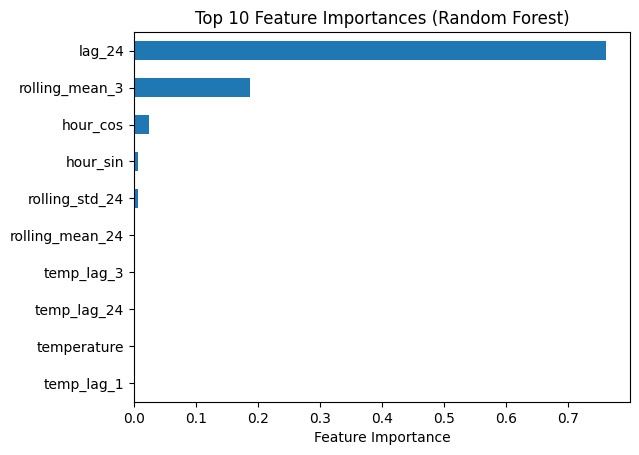

In [15]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

ax = feature_importance.head(10).plot(kind='barh')
ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  
plt.show()

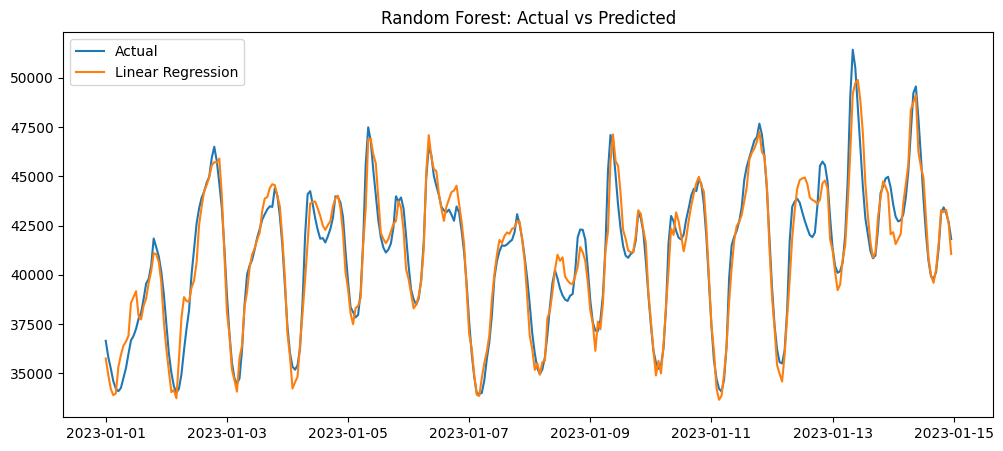

In [16]:
rf_test_pred = pd.Series(rf_test_pred, index=y_test.index) # Convert predictions to a Pandas Series

subset = y_test.loc["2023-01-01":"2023-01-14"]

plt.figure(figsize=(12,5))
plt.plot(subset.index, subset, label="Actual")
plt.plot(subset.index, rf_test_pred.loc[subset.index], label="Linear Regression")
plt.legend()
plt.title("Random Forest: Actual vs Predicted")
plt.show()

## XGBoost Regressor

XGBoost is a gradient boosting algorithm that builds trees sequentially,
where each tree learns to correct the errors of the previous ones.

It is highly effective for tabular data and often outperforms other models
by capturing complex nonlinear relationships and interactions.

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_val_pred = xgb.predict(X_val)
xgb_test_pred = xgb.predict(X_test)

xgb_val_metrics = evaluate_model("XGBoost", y_val, xgb_val_pred)
xgb_test_metrics = evaluate_model("XGBoost", y_test, xgb_test_pred)

print("Validation:", xgb_val_metrics)
print("Test:", xgb_test_metrics)

Validation: {'model': 'XGBoost', 'MAE': 907.4880070098459, 'MAPE': 1.7965368405336943}
Test: {'model': 'XGBoost', 'MAE': 1360.8455755921805, 'MAPE': 2.400367809793104}


In [18]:
# Saving Best Model
import joblib

joblib.dump(xgb, "../models/xgb_demand_model.joblib")

['../models/xgb_demand_model.joblib']

lag_24            0.715747
rolling_mean_3    0.195006
hour_cos          0.030228
hour_sin          0.011220
temp_lag_3        0.008915
rolling_std_24    0.006923
is_weekend        0.004763
temp_lag_1        0.004748
temp_lag_24       0.004732
dow_cos           0.003473
dtype: float32


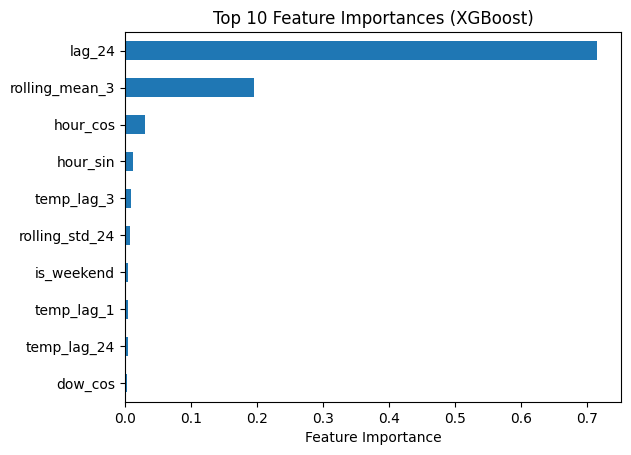

In [19]:
# Feature Importance in XGBoost
feature_importance_xgb = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance_xgb.head(10))

ax = feature_importance_xgb.head(10).plot(kind='barh')
ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()  
plt.savefig("../reports/plots/feature_importance_xgb.png")
plt.show()


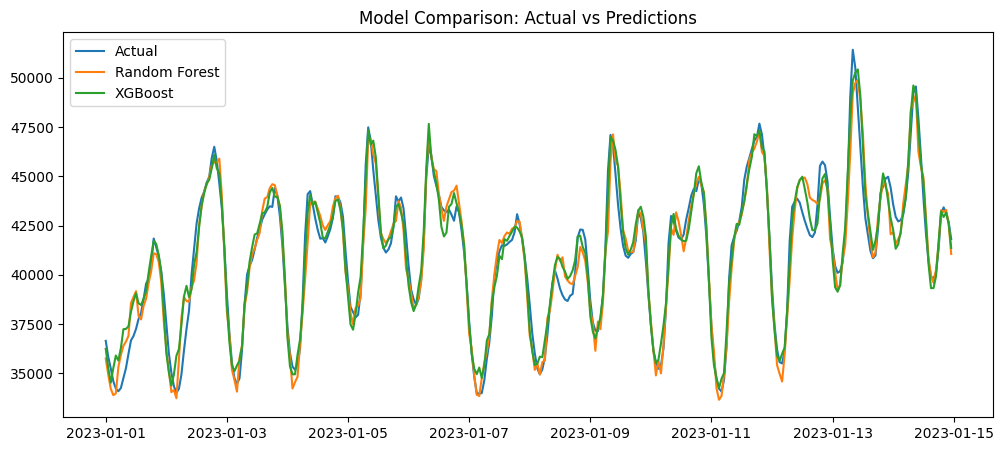

In [20]:
xgb_test_pred =  pd.Series(xgb_test_pred, index=y_test.index) # Convert predictions to a Pandas Series

subset = y_test.loc["2023-01-01":"2023-01-14"]

plt.figure(figsize=(12,5))
plt.plot(subset.index, subset, label="Actual")
plt.plot(subset.index, rf_test_pred.loc[subset.index], label="Random Forest")
plt.plot(subset.index, xgb_test_pred.loc[subset.index], label="XGBoost")

plt.legend()
plt.title("Model Comparison: Actual vs Predictions")
plt.savefig("../reports/plots/final_predictions_comparison.png")
plt.show()


In [21]:
# Analyze hourly demand patterns and save thresholds for different demand levels (e.g., 25th, 75th, and 90th percentiles) to identify peak and off-peak hours.
df["hour"] = df.index.hour

hourly_thresholds = df.groupby("hour")["demand_MW"].quantile([0.25, 0.75, 0.90, 0.99]).unstack()
hourly_thresholds.columns = ["p25", "p75", "p90", "p99"]
hourly_thresholds["mean"] = df.groupby("hour")["demand_MW"].mean()

hourly_thresholds.to_csv("../reports/hourly_demand_thresholds.csv")
print("Saved")
print(hourly_thresholds.head())

Saved
           p25       p75      p90       p99          mean
hour                                                     
0     36763.00  48731.75  54952.7  66433.92  43350.250733
1     35055.75  45829.50  51608.4  62940.55  41053.708288
2     33927.50  43786.75  49104.0  59784.38  39471.091712
3     33271.75  42443.25  47417.8  57249.63  38447.582051
4     33035.50  41648.25  46445.6  55686.77  37935.787363


In [22]:
# Calculate thresholds for demand categorization
thresholds = {
    "p25": float(df["demand_MW"].quantile(0.25)),
    "p75": float(df["demand_MW"].quantile(0.75)),
    "p90": float(df["demand_MW"].quantile(0.90)),
    "mean": float(df["demand_MW"].mean()),
    "std": float(df["demand_MW"].std())
}

import json
with open("../reports/demand_thresholds.json", "w") as f:
    json.dump(thresholds, f, indent=2)

print(thresholds)

{'p25': 38302.0, 'p75': 51292.25, 'p90': 61918.0, 'mean': 45855.75059142247, 'std': 10582.148964723985}


In [23]:
# Save a median row for app defaults
sample_row = X_test.median().to_frame().T
sample_row.to_csv("../reports/app_demand_defaults.csv", index=False)
print("Saved")
print(sample_row.shape)

Saved
(1, 18)


               model          MAE      MAPE
0  Baseline (Lag-24)  2298.790000  4.650000
1  Linear Regression  1455.455623  2.870559
2      Decision Tree  1928.851716  3.576639
3      Random Forest  1425.873658  2.536394
4            XGBoost  1360.845576  2.400368


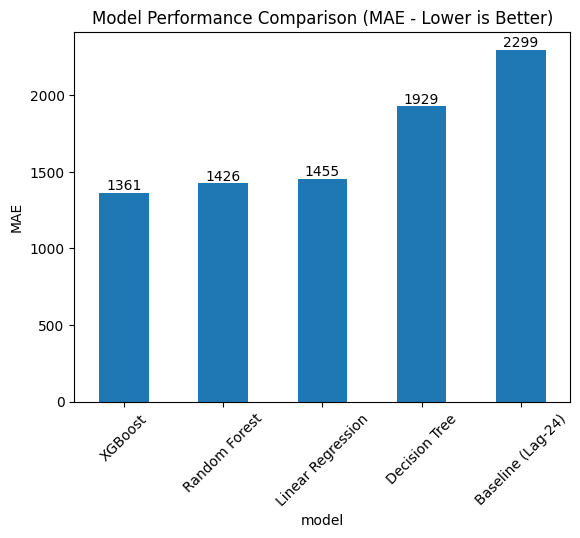

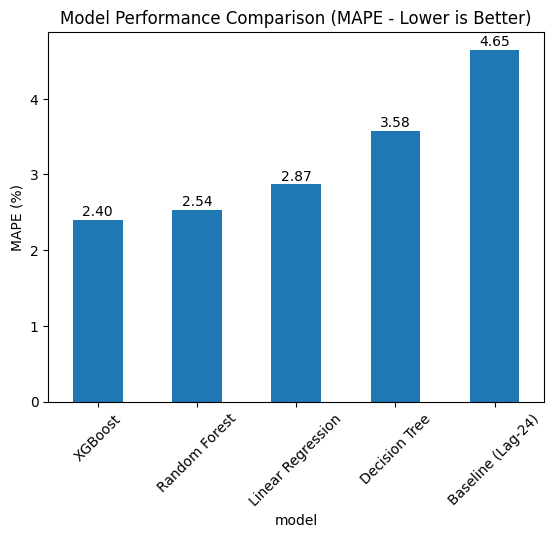

In [24]:
results = []

results.append(baseline_test_metrics)
results.append(lr_test_metrics)
results.append(tree_test_metrics)
results.append(rf_test_metrics)
results.append(xgb_test_metrics)

results_df = pd.DataFrame(results)
print(results_df)

results_df_sorted = results_df.sort_values(by="MAE")

# MAE Plot
ax = results_df_sorted.set_index("model")["MAE"].plot(kind="bar")
for i, v in enumerate(results_df_sorted["MAE"]):
    ax.text(i, v + 20, f"{v:.0f}", ha='center')
plt.title("Model Performance Comparison (MAE - Lower is Better)")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.savefig("../reports/plots/model_comparison_mae.png")
plt.show()

# MAPE Plot
ax = results_df_sorted.set_index("model")["MAPE"].plot(kind="bar")
for i, v in enumerate(results_df_sorted["MAPE"]):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center')
plt.title("Model Performance Comparison (MAPE - Lower is Better)")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.savefig("../reports/plots/model_comparison_mape.png")
plt.show()

results_df.to_csv("../reports/summary_tables/model_results.csv", index=False)

## Model Comparison

The performance of all models is summarized below:

| Model                   | MAE (MW) | MAPE (%) |
| ----------------------- | -------- | -------- |
| Seasonal Naive (Lag-24) | ~2299    | ~4.65    |
| Linear Regression       | ~1455    | ~2.87   |
| Decision Tree           | ~1929    | ~3.57    |
| Random Forest           | ~1426    | ~2.53    |
| XGBoost                 | ~1360    | ~2.40    |

### Observations

* The **seasonal naive baseline** performs reasonably well due to strong daily patterns in electricity demand.
* **Linear Regression** significantly improves performance by leveraging lag features, calendar variables, and temperature.
* The **Decision Tree** model underperforms compared to linear regression and shows signs of overfitting.
* **Random Forest** reduces overfitting and captures nonlinear relationships, leading to substantial improvement.
* **XGBoost** achieves the best performance by sequentially correcting errors and modeling complex interactions.

Overall, ensemble methods outperform simpler models, demonstrating the importance of capturing nonlinear patterns in electricity demand.


## Final Model: XGBoost

XGBoost provides the best performance among all models evaluated.

Unlike Random Forest, which builds trees independently, XGBoost constructs trees sequentially, where each new tree learns to correct the errors of the previous ones.

To prevent overfitting, shallow trees (max_depth = 6) are used, ensuring that each tree acts as a weak learner. Combined with a low learning rate, this allows the model to gradually improve predictions while maintaining generalization.

The results indicate that boosting methods are highly effective for tabular time-series forecasting tasks involving complex feature interactions.


## Conclusion

This project demonstrates an end-to-end approach to electricity demand forecasting using time-series feature engineering and machine learning models.

Key insights:

* Electricity demand exhibits strong **daily and weekly seasonality**, making lag-based features highly predictive.
* Feature engineering plays a critical role — simple models like linear regression can perform well when provided with meaningful features.
* Tree-based models capture nonlinear relationships, particularly between temperature and demand.
* Ensemble methods significantly improve performance:

  * Random Forest reduces overfitting by averaging multiple trees
  * XGBoost further improves accuracy through sequential learning

The final XGBoost model achieves the best performance, reducing prediction error substantially compared to the baseline.

### Key Takeaway

A combination of **domain-aware feature engineering and ensemble learning methods** is essential for building accurate and reliable electricity demand forecasting models.


## Future Improvements

* Incorporate **weather forecast data** instead of historical temperature for true real-world deployment
* Use **rolling cross-validation** for more robust evaluation
* Explore **probabilistic forecasting** to estimate uncertainty
* Extend to **multi-step forecasting** for longer horizons
